In [ ]:
import csv
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from emmaemb.core import Emma
sys.path.append('/home/unix/vkrhk/EmmaEmb/analysis')

IMG_OUTPUT_PATH = '/home/unix/vkrhk/EmmaEmb/img'
DATA_PATH = '/home/unix/vkrhk/EmmaEmb/data'
EMBEDDINGS_PATH = '/media/drive2/vkrhk/embeddings'

def prepare_data(datasets, emb_spaces, subset_size=None):
    # colect data:
    feature_data = []
    embeddings = {}

    for dataset in datasets:
        with open(f'{DATA_PATH}/{dataset}', 'r') as f:
            reader = csv.reader(f, delimiter=';')
            for ii, row in enumerate(reader):
                protein_id = row[0] + row[1]
                annotation = row[3].split(' ')
                annotation = [int(i[1:]) for i in annotation]
                sequence = row[4]

                these_embeddings = {}
                length, have_same_length = 0, True
                for i, (embeddings_name, embeddings_path) in enumerate(emb_spaces):
                    path = f"{embeddings_path}/{protein_id}.npy"
                    if not os.path.exists(path):
                        have_same_length = False
                        break
                    embedding = np.load(path)
                    these_embeddings[embeddings_name] = embedding
                    # check that all embedding spaces have the same length for this protein
                    if i == 0:
                        length = embedding.shape[0]
                    else:
                        if embedding.shape[0] != length:
                            have_same_length = False
                            break

                if not have_same_length:
                    continue
                
                BINDING_FLAG = 'CRYPTIC-BINDING' if dataset == 'train.txt' else 'BINDING'
                for i in range(len(sequence)):
                    feature_data.append([sequence[i], BINDING_FLAG if i in annotation else 'NON-BINDING'])

                for embeddings_name in these_embeddings:
                    if embeddings_name not in embeddings:
                        embeddings[embeddings_name] = []
                    embeddings[embeddings_name].append(these_embeddings[embeddings_name])
                if subset_size is not None and ii > subset_size:
                    break
                
    for embeddings_name in embeddings:
        concatenated_embeddings_path = f"{EMBEDDINGS_PATH}/concatenated-embeddings/{embeddings_name}_binding_site_embeddings.npy"
        embeddings[embeddings_name] = np.concatenate(embeddings[embeddings_name], axis=0)
        np.save(concatenated_embeddings_path, embeddings[embeddings_name])  

    feature_data = pd.DataFrame.from_records(feature_data, columns=["amino acid", "binding_site"])

    # initiate Emma object and load embedding spaces
    emma = Emma(feature_data=feature_data)
    for embeddings_name, _ in emb_spaces:
        emma.add_emb_space(
            embeddings_source=f"{EMBEDDINGS_PATH}/concatenated-embeddings/{embeddings_name}_binding_site_embeddings.npy",
            emb_space_name=embeddings_name)
    return emma, embeddings

def perform_linear_probing(emma, embeddings):
    for embeddings_name in embeddings:

        # 1. Prepare your data
        # X: Your raw embeddings (Shape: [n_residues, embedding_dim])
        # y: Your labels (0 for non-binding, 1 for binding)
        X = embeddings[embeddings_name]
        y = emma.metadata["binding_site"].apply(lambda x: 1 if x == 'BINDING' else 2 if x == 'CRYPTIC-BINDING' else 0).values

        # 2. Split with stratification (crucial for rare classes like 'cryptic')
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )

        # 3. Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 4. Multiclass Linear Probe
        # multi_class='multinomial' uses the cross-entropy loss (softmax)
        probe = LogisticRegression(
            max_iter=2000, 
            class_weight='balanced', 
            random_state=42
        )

        probe.fit(X_train_scaled, y_train)

        # 5. Predictions
        y_pred = probe.predict(X_test_scaled)
        y_prob = probe.predict_proba(X_test_scaled) # Returns [n_samples, 3]

        # 6. Evaluation
        print(f"--- 3-Class Linear Probe Results: {embeddings_name} ---")
        # Use 'macro' average to give equal weight to the 'Cryptic' class
        print(classification_report(y_test, y_pred, target_names=['Non-binding', 'Regular', 'Cryptic']))

        # Multiclass ROC-AUC (One-vs-Rest)
        auc_ovr = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
        print(f"Multiclass ROC-AUC (OVR): {auc_ovr:.4f}")

        # 7. Static Visualization: Confusion Matrix
        cm = confusion_matrix(y_test, y_pred, normalize='true') # Normalized by row (true labels)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                    xticklabels=['Non-binding', 'Regular', 'Cryptic'], 
                    yticklabels=['Non-binding', 'Regular', 'Cryptic'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Normalized Confusion Matrix: Binding Site Types')
        plt.show()

561829 samples loaded.
Categories in meta data: ['binding_site']
Numerical columns in meta data: []
Embedding space 'ESM2' added successfully.
Embeddings have 1280 features each.
--- 3-Class Linear Probe Results: ESM2 ---
              precision    recall  f1-score   support

 Non-binding       0.97      0.73      0.83    100005
     Regular       0.24      0.54      0.33      9708
     Cryptic       0.10      0.61      0.18      2653

    accuracy                           0.71    112366
   macro avg       0.44      0.62      0.45    112366
weighted avg       0.88      0.71      0.77    112366

Multiclass ROC-AUC (OVR): 0.8272


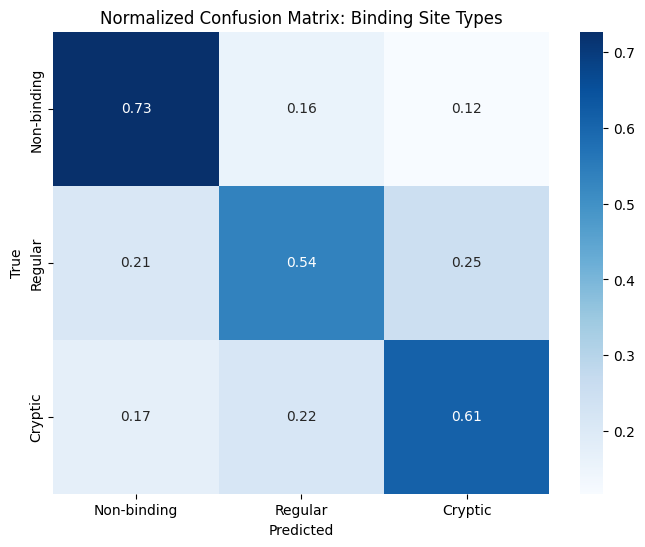

In [3]:
emb_spaces = [("ESM2", f"{EMBEDDINGS_PATH}/esm2_t33_650M_UR50D/layer_33/chopped_1022_overlap_300"),
# ("ANKH", f"{EMBEDDINGS_PATH}/ankh_base/layer_None/chopped_1022_overlap_300"),
# ("ProstT5", f"{EMBEDDINGS_PATH}/Rostlab/ProstT5/layer_None/chopped_1022_overlap_300/"),
# ("ProtT5", f"{EMBEDDINGS_PATH}/Rostlab/prot_t5_xl_uniref50/layer_None/chopped_1022_overlap_300"),
# ("ESM1", f"{EMBEDDINGS_PATH}/esm1_t34_670M_UR100/layer_34/chopped_1022_overlap_300/"),
# ("ESMC", f"{EMBEDDINGS_PATH}/esmc-300m-2024-12/layer_None/chopped_1022_overlap_300/"),
]

emma, embeddings = prepare_data(datasets=['train.txt', 'scPDB_enhanced_binding_sites_translated.csv'], emb_spaces=emb_spaces, subset_size=1000)
perform_linear_probing(emma, embeddings)

--- 3-Class Linear Probe Results: ESM2 ---
              precision    recall  f1-score   support

 Non-binding       0.96      0.83      0.89      6076
     Regular       0.28      0.68      0.40       422
     Cryptic       0.22      0.50      0.31       180

    accuracy                           0.81      6678
   macro avg       0.49      0.67      0.53      6678
weighted avg       0.90      0.81      0.85      6678

Multiclass ROC-AUC (OVR): 0.8582


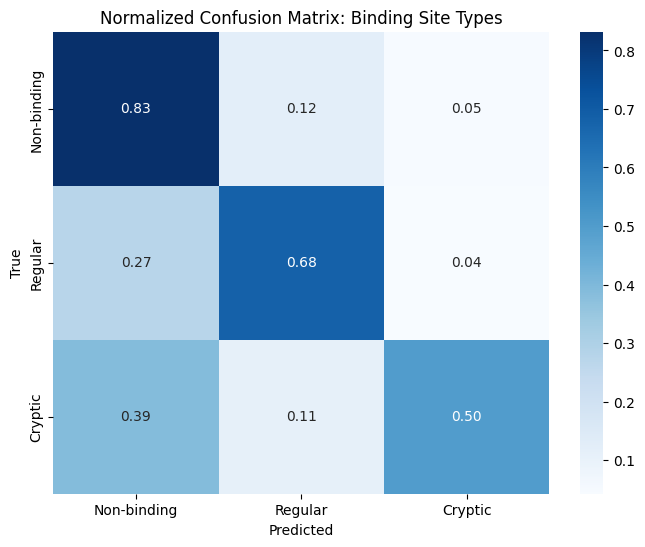

--- 3-Class Linear Probe Results: ANKH ---
              precision    recall  f1-score   support

 Non-binding       0.96      0.85      0.90      6076
     Regular       0.27      0.64      0.38       422
     Cryptic       0.25      0.46      0.32       180

    accuracy                           0.82      6678
   macro avg       0.49      0.65      0.53      6678
weighted avg       0.90      0.82      0.85      6678

Multiclass ROC-AUC (OVR): 0.8539


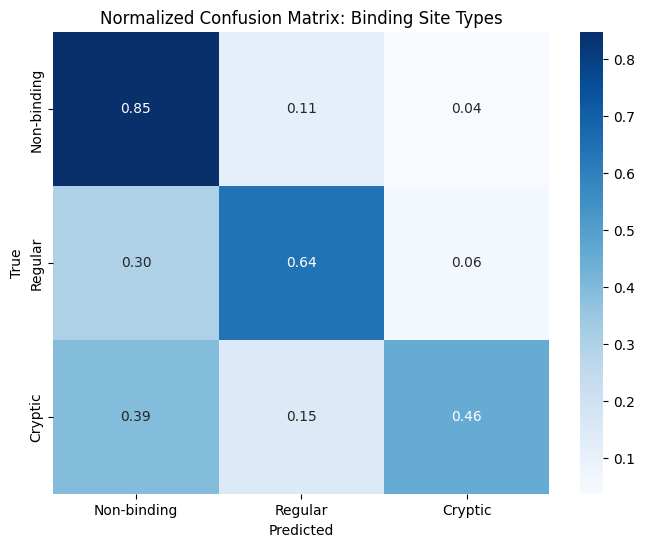

--- 3-Class Linear Probe Results: ProstT5 ---
              precision    recall  f1-score   support

 Non-binding       0.96      0.77      0.86      6076
     Regular       0.22      0.61      0.32       422
     Cryptic       0.16      0.57      0.25       180

    accuracy                           0.75      6678
   macro avg       0.45      0.65      0.47      6678
weighted avg       0.90      0.75      0.81      6678

Multiclass ROC-AUC (OVR): 0.8343


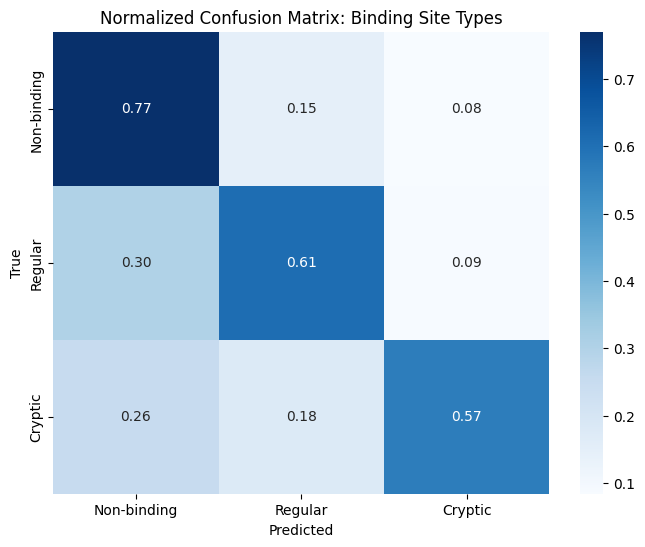

--- 3-Class Linear Probe Results: ProtT5 ---
              precision    recall  f1-score   support

 Non-binding       0.97      0.80      0.88      6076
     Regular       0.24      0.64      0.35       422
     Cryptic       0.19      0.58      0.28       180

    accuracy                           0.78      6678
   macro avg       0.47      0.67      0.50      6678
weighted avg       0.90      0.78      0.83      6678

Multiclass ROC-AUC (OVR): 0.8670


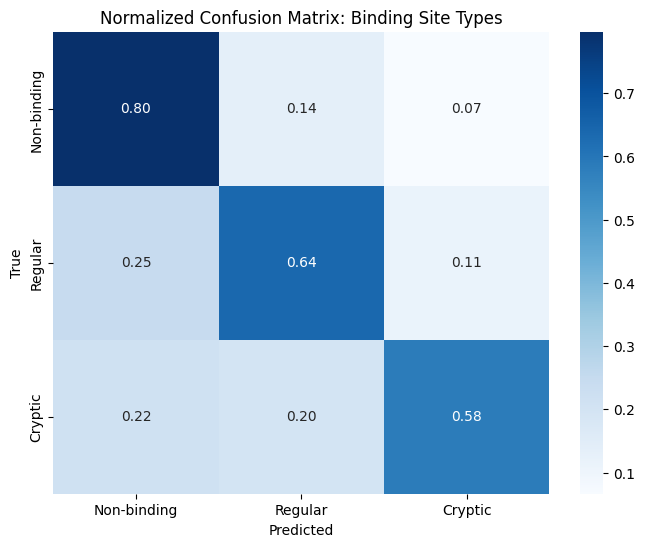

--- 3-Class Linear Probe Results: ESM1 ---
              precision    recall  f1-score   support

 Non-binding       0.96      0.80      0.88      6076
     Regular       0.25      0.67      0.37       422
     Cryptic       0.20      0.53      0.29       180

    accuracy                           0.79      6678
   macro avg       0.47      0.67      0.51      6678
weighted avg       0.90      0.79      0.83      6678

Multiclass ROC-AUC (OVR): 0.8635


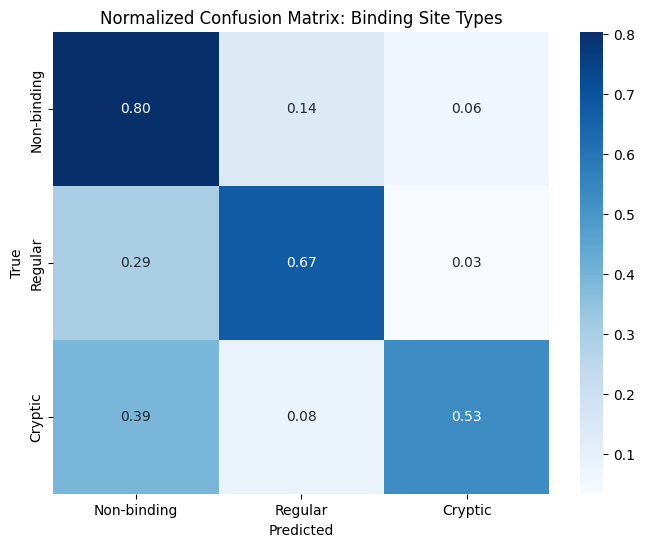

--- 3-Class Linear Probe Results: ESMC ---
              precision    recall  f1-score   support

 Non-binding       0.97      0.77      0.86      6076
     Regular       0.23      0.66      0.34       422
     Cryptic       0.15      0.54      0.24       180

    accuracy                           0.76      6678
   macro avg       0.45      0.66      0.48      6678
weighted avg       0.90      0.76      0.81      6678

Multiclass ROC-AUC (OVR): 0.8528


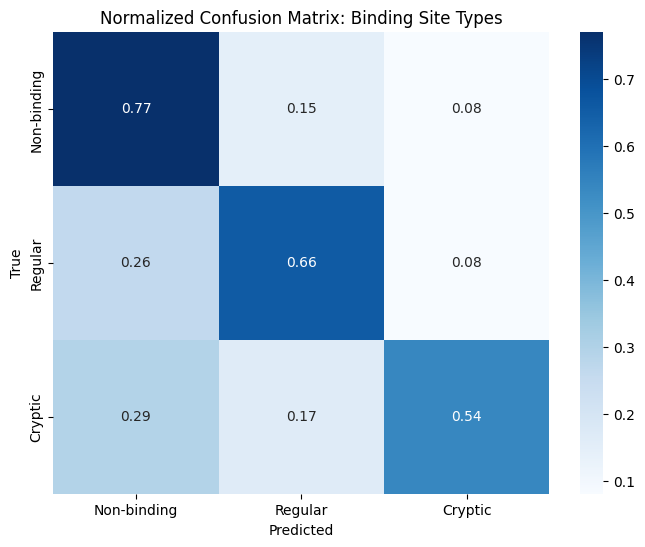

In [ ]:
emma, embeddings = prepare_data(datasets=['train.txt', 'scPDB_enhanced_binding_sites_translated.csv'], emb_spaces=emb_spaces)
perform_linear_probing(emma, embeddings)

/home/unix/vkrhk/miniconda3/envs/emmaemb/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- 3-Class Linear Probe Results: Evo2 ---
              precision    recall  f1-score   support

 Non-binding       0.95      0.60      0.73     49718
     Cryptic       0.06      0.46      0.11      2906

    accuracy                           0.59     52624
   macro avg       0.51      0.53      0.42     52624
weighted avg       0.90      0.59      0.70     52624

Binary ROC-AUC: 0.5383


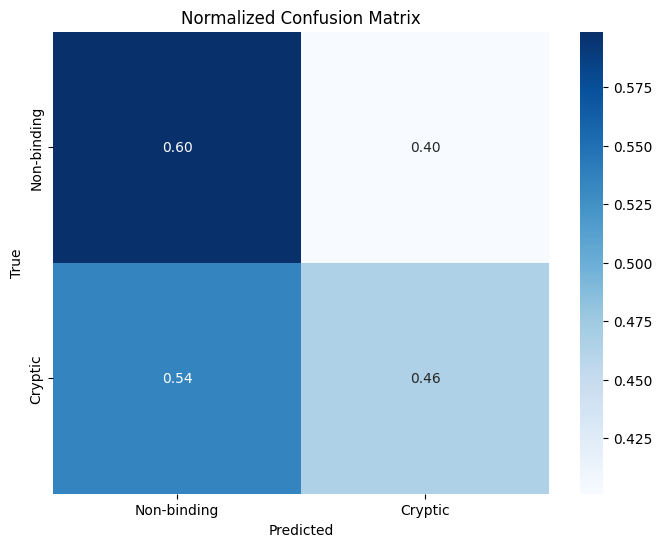

In [2]:
emb_spaces = [("Evo2", "/media/drive2/vkrhk/embeddings/genes")]
datasets = ['cryptobench-with-sequence.csv']

emma, embeddings = prepare_data(datasets=datasets, emb_spaces=emb_spaces)
perform_linear_probing(emma, embeddings)

230263 samples loaded.
Categories in meta data: ['binding_site']
Numerical columns in meta data: []
Embedding space 'ESM2' added successfully.
Embeddings have 1280 features each.
--- 3-Class Linear Probe Results: ESM2 ---
              precision    recall  f1-score   support

 Non-binding       0.98      0.81      0.89     43400
     Cryptic       0.20      0.76      0.31      2653

    accuracy                           0.81     46053
   macro avg       0.59      0.79      0.60     46053
weighted avg       0.94      0.81      0.85     46053

Binary ROC-AUC: 0.8646


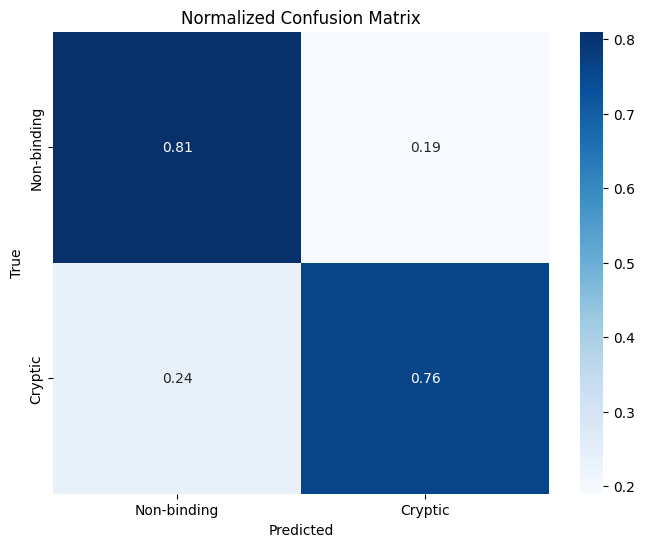

In [3]:
emb_spaces = [("ESM2", f"{EMBEDDINGS_PATH}/esm2_t33_650M_UR50D/layer_33/chopped_1022_overlap_300")]
datasets = ['train.txt']

emma, embeddings = prepare_data(datasets=datasets, emb_spaces=emb_spaces)
perform_linear_probing(emma, embeddings)

230263 samples loaded.
Categories in meta data: ['binding_site']
Numerical columns in meta data: []
Embedding space 'ESM1' added successfully.
Embeddings have 1280 features each.
--- 3-Class Linear Probe Results: ESM1 ---
              precision    recall  f1-score   support

 Non-binding       0.98      0.76      0.85     43400
     Cryptic       0.16      0.74      0.26      2653

    accuracy                           0.76     46053
   macro avg       0.57      0.75      0.56     46053
weighted avg       0.93      0.76      0.82     46053

Binary ROC-AUC: 0.8255


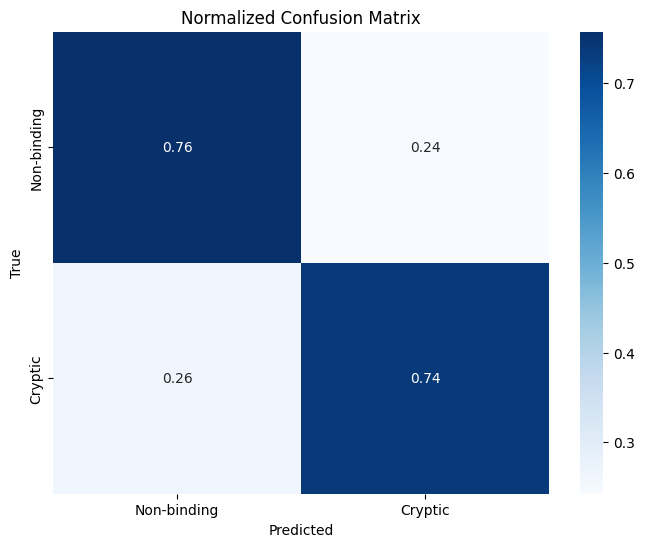

In [5]:
emb_spaces = [("ESM1", f"{EMBEDDINGS_PATH}/esm1_t34_670M_UR100/layer_34/chopped_1022_overlap_300")]
datasets = ['train.txt']

emma, embeddings = prepare_data(datasets=datasets, emb_spaces=emb_spaces)
perform_linear_probing(emma, embeddings)